In [1]:
import pandas as pd
import matplotlib.pyplot as plt


data_frame = pd.read_csv("iris_sujo.csv")

data_frame

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,NaN,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


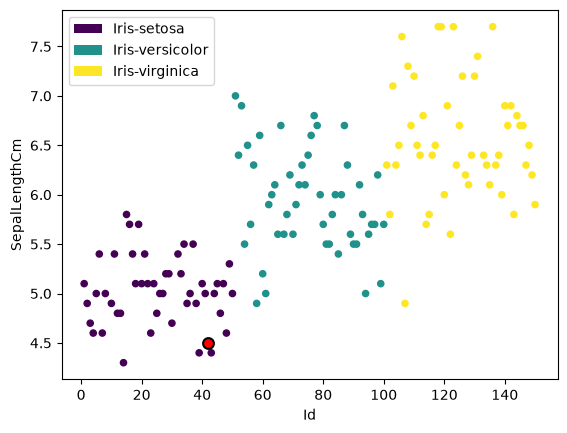

In [2]:
data_plot = data_frame.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'SepalLengthCm', c = 'Species')

plt.scatter(
    data_plot.loc[data_plot['Id'] == 42, 'Id'],
    data_plot.loc[data_plot['Id'] == 42, 'SepalLengthCm'],
    color='red',  # Cor diferente
    s=60,
    edgecolor='black',  # Borda para destacar
    linewidth=1.5,
    label='Flor ID 42',
    zorder=5,  # Garante que fique na frente dos outros pontos
)


<Axes: xlabel='Id', ylabel='SepalWidthCm'>

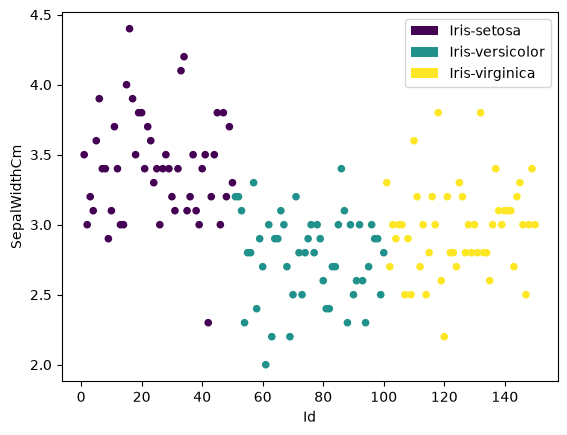

In [3]:
data_plot = data_frame.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'SepalWidthCm', c = 'Species')

<Axes: xlabel='Id', ylabel='PetalLengthCm'>

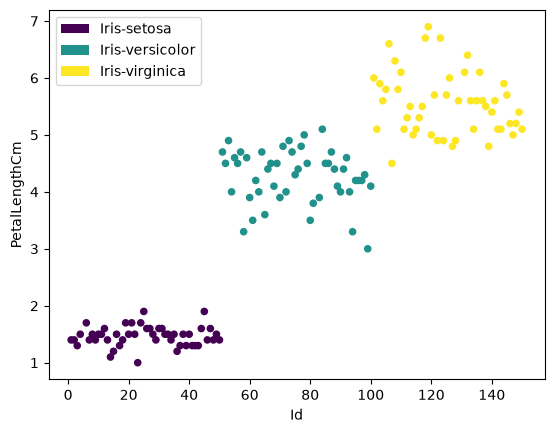

In [4]:
data_plot = data_frame.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'PetalLengthCm', c = 'Species')

<Axes: xlabel='Id', ylabel='PetalWidthCm'>

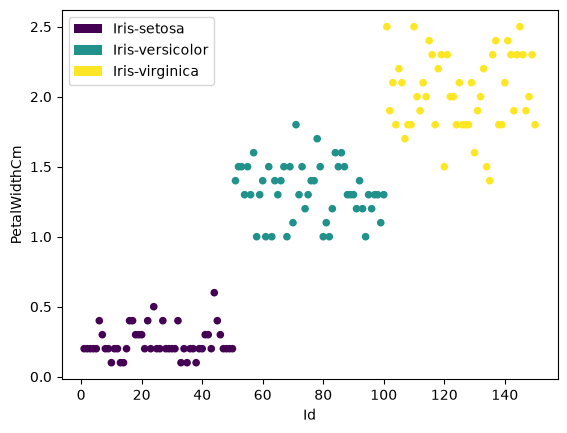

In [5]:
data_plot = data_frame.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'PetalWidthCm', c = 'Species')

In [6]:
numeric_cols = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

for col in numeric_cols:
  data_frame[col] = data_frame[col].fillna(data_frame.groupby('Species')[col].transform('median'))

data_frame

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.5,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
data_frame.to_csv("iris_sem_nulos.csv", index=False)

<Axes: xlabel='Id', ylabel='SepalLengthCm'>

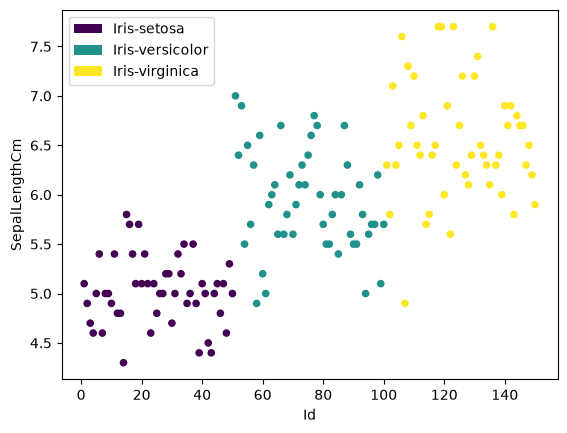

In [8]:
#Pós tratamento dos não nulos

df = pd.read_csv("iris_sem_nulos.csv")

data_plot = df.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'SepalLengthCm', c = 'Species')


<Axes: xlabel='Id', ylabel='SepalWidthCm'>

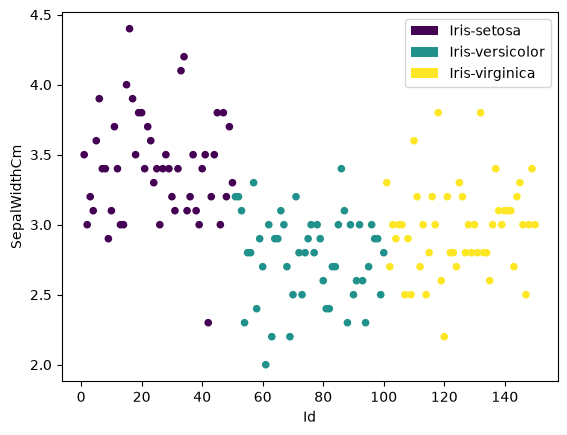

In [9]:
data_plot = df.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'SepalWidthCm', c = 'Species')

<Axes: xlabel='Id', ylabel='PetalLengthCm'>

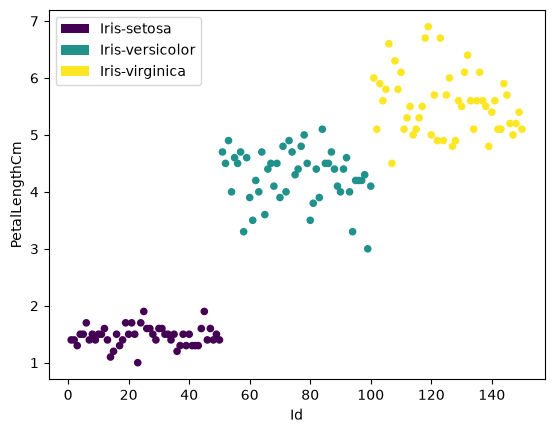

In [10]:
data_plot = df.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'PetalLengthCm', c = 'Species')

<Axes: xlabel='Id', ylabel='PetalWidthCm'>

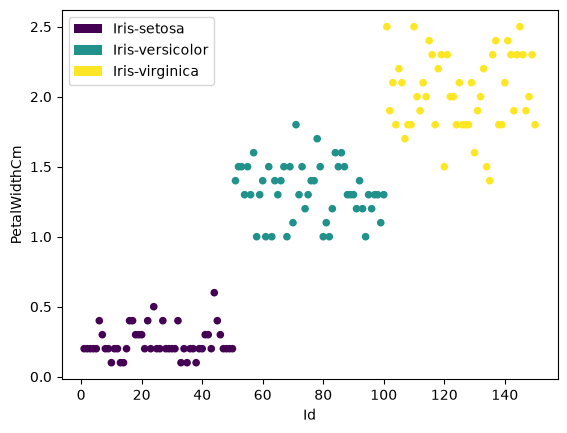

In [11]:
data_plot = df.reset_index()

data_plot.plot.scatter(x = 'Id', y = 'PetalWidthCm', c = 'Species')

In [14]:
cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1

  limite_inferior = q1 - 1.5 * iqr
  limite_superior = q3 + 1.5 * iqr

  # Cria uma coluna com nome dinâmico para cada variável
  df[f'outlier_{col}'] = (df[col] < limite_inferior) | (
      df[col] > limite_superior
  )

  print(f'=== {col} ===')
  print('Q1:', q1)
  print('Q3:', q3)
  print('IQR:', iqr)
  print('Limite inferior:', limite_inferior)
  print('Limite superior:', limite_superior)
  print('Outliers encontrados:', df[f'outlier_{col}'].sum())
  print('-' * 30)

df


=== SepalLengthCm ===
Q1: 5.1
Q3: 6.4
IQR: 1.3000000000000007
Limite inferior: 3.1499999999999986
Limite superior: 8.350000000000001
Outliers encontrados: 0
------------------------------
=== SepalWidthCm ===
Q1: 2.8
Q3: 3.3
IQR: 0.5
Limite inferior: 2.05
Limite superior: 4.05
Outliers encontrados: 4
------------------------------
=== PetalLengthCm ===
Q1: 1.6
Q3: 5.1
IQR: 3.4999999999999996
Limite inferior: -3.649999999999999
Limite superior: 10.349999999999998
Outliers encontrados: 0
------------------------------
=== PetalWidthCm ===
Q1: 0.3
Q3: 1.8
IQR: 1.5
Limite inferior: -1.95
Limite superior: 4.05
Outliers encontrados: 0
------------------------------


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,outlier_iqr,outlier_SepalLengthCm,outlier_SepalWidthCm,outlier_PetalLengthCm,outlier_PetalWidthCm
0,1,5.1,3.5,1.4,0.2,Iris-setosa,False,False,False,False,False
1,2,4.9,3.0,1.4,0.2,Iris-setosa,False,False,False,False,False
2,3,4.7,3.2,1.3,0.2,Iris-setosa,False,False,False,False,False
3,4,4.6,3.1,1.5,0.2,Iris-setosa,False,False,False,False,False
4,5,5.0,3.6,1.5,0.2,Iris-setosa,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,False,False,False,False,False
146,147,6.3,2.5,5.0,1.9,Iris-virginica,False,False,False,False,False
147,148,6.5,3.0,5.2,2.0,Iris-virginica,False,False,False,False,False
148,149,6.2,3.4,5.4,2.3,Iris-virginica,False,False,False,False,False
